In [1]:
import hoomd
import matplotlib

%matplotlib inline
matplotlib.style.use("ggplot")
import matplotlib_inline

matplotlib_inline.backend_inline.set_matplotlib_formats("svg")

In [2]:
cpu = hoomd.device.CPU()
simulation = hoomd.Simulation(device=cpu, seed=1)
simulation.create_state_from_gsd(
    filename="random.gsd"
)

integrator = hoomd.md.Integrator(dt=0.005)
cell = hoomd.md.nlist.Cell(buffer=0.4)
lj = hoomd.md.pair.LJ(nlist=cell)
lj.params[("A", "A")] = dict(epsilon=1, sigma=1)
lj.r_cut[("A", "A")] = 2.5
integrator.forces.append(lj)
nvt = hoomd.md.methods.ConstantVolume(
    filter=hoomd.filter.All(), thermostat=hoomd.md.methods.thermostats.Bussi(kT=1.5)
)
integrator.methods.append(nvt)
simulation.operations.integrator = integrator
simulation.run(0)

In [3]:
simulation.loggables

{'timestep': 'scalar',
 'seed': 'scalar',
 'tps': 'scalar',
 'walltime': 'scalar',
 'final_timestep': 'scalar',
 'initial_timestep': 'scalar'}

In [4]:
thermodynamic_properties = hoomd.md.compute.ThermodynamicQuantities(
    filter=hoomd.filter.All()
)
simulation.operations.computes.append(thermodynamic_properties)
thermodynamic_properties.loggables

{'kinetic_temperature': 'scalar',
 'pressure': 'scalar',
 'pressure_tensor': 'sequence',
 'kinetic_energy': 'scalar',
 'translational_kinetic_energy': 'scalar',
 'rotational_kinetic_energy': 'scalar',
 'potential_energy': 'scalar',
 'degrees_of_freedom': 'scalar',
 'translational_degrees_of_freedom': 'scalar',
 'rotational_degrees_of_freedom': 'scalar',
 'num_particles': 'scalar',
 'volume': 'scalar'}

In [5]:
simulation.timestep

10000

In [6]:
thermodynamic_properties.kinetic_temperature

1.4869176338328167

In [7]:
logger = hoomd.logging.Logger(categories=["scalar", "sequence"])

In [8]:
logger.add(thermodynamic_properties)

In [9]:
logger.add(simulation, quantities=["timestep", "walltime"])

## Writing Log Quantities to a File

In [10]:
hdf5_writer = hoomd.write.HDF5Log(
    trigger=hoomd.trigger.Periodic(1000), filename="log.h5", mode="w", logger=logger
)
simulation.operations.writers.append(hdf5_writer)

In [11]:
simulation.run(100_000)

In [12]:
simulation.operations.writers.remove(hdf5_writer)

## Reading Logged Data From a HDF5 File

In [13]:
!h5ls -r log.h5

/                        Group
/hoomd-data              Group
/hoomd-data/Simulation   Group
/hoomd-data/Simulation/timestep Dataset {100/Inf}
/hoomd-data/Simulation/walltime Dataset {100/Inf}
/hoomd-data/md           Group
/hoomd-data/md/compute   Group
/hoomd-data/md/compute/ThermodynamicQuantities Group
/hoomd-data/md/compute/ThermodynamicQuantities/degrees_of_freedom Dataset {100/Inf}
/hoomd-data/md/compute/ThermodynamicQuantities/kinetic_energy Dataset {100/Inf}
/hoomd-data/md/compute/ThermodynamicQuantities/kinetic_temperature Dataset {100/Inf}
/hoomd-data/md/compute/ThermodynamicQuantities/num_particles Dataset {100/Inf}
/hoomd-data/md/compute/ThermodynamicQuantities/potential_energy Dataset {100/Inf}
/hoomd-data/md/compute/ThermodynamicQuantities/pressure Dataset {100/Inf}
/hoomd-data/md/compute/ThermodynamicQuantities/pressure_tensor Dataset {100/Inf, 6}
/hoomd-data/md/compute/ThermodynamicQuantities/rotational_degrees_of_freedom Dataset {100/Inf}
/hoomd-data/md/compute/Thermo

In [14]:
!h5dump -d /hoomd-data/md/compute/ThermodynamicQuantities/potential_energy log.h5

HDF5 "log.h5" {
DATASET "/hoomd-data/md/compute/ThermodynamicQuantities/potential_energy" {
   DATATYPE  H5T_IEEE_F64LE
   DATASPACE  SIMPLE { ( 100 ) / ( H5S_UNLIMITED ) }
   DATA {
   (0): -554.557, -528.312, -537.645, -552.026, -530.789, -542.63, -547.562,
   (7): -528.375, -535.339, -527.098, -533.693, -523.851, -552.322, -550.101,
   (14): -538.302, -548.204, -542.054, -541.024, -544.114, -555.7, -501.472,
   (21): -524.871, -550.085, -547.926, -533.244, -544.173, -555.491,
   (27): -553.268, -548.942, -542.181, -545.067, -540.76, -530.109, -526.825,
   (34): -560.731, -566.225, -529.244, -551.614, -557.166, -543.413, -548.01,
   (41): -533, -568.888, -545.432, -573.702, -537.038, -535.326, -526.078,
   (48): -550.915, -574.644, -540.514, -542.535, -556.74, -531.191, -527.317,
   (55): -539.265, -538.808, -523.92, -548.395, -516.814, -566.125, -517.35,
   (62): -527.401, -536.615, -545.912, -539.933, -535.542, -553.76, -540.788,
   (69): -547.498, -530.484, -561.313, -529.468, -56

In [15]:
import h5py

hdf5_file = h5py.File(name="log.h5", mode="r")

In [16]:
hdf5_file["hoomd-data/md/compute/ThermodynamicQuantities/potential_energy"]

<HDF5 dataset "potential_energy": shape (100,), type "<f8">

In [17]:
hdf5_file["hoomd-data/md/compute/ThermodynamicQuantities/potential_energy"][:]

array([-554.55694064, -528.31201789, -537.64528051, -552.02587207,
       -530.78907644, -542.63046146, -547.56218591, -528.3753444 ,
       -535.3388809 , -527.09806556, -533.69316665, -523.85080403,
       -552.32222981, -550.10090677, -538.30208448, -548.20367706,
       -542.05393814, -541.02430956, -544.11386395, -555.69954634,
       -501.47186479, -524.87098853, -550.08467784, -547.92637576,
       -533.24355847, -544.17279303, -555.49095768, -553.26849403,
       -548.94193779, -542.18052334, -545.06693094, -540.7596925 ,
       -530.10895618, -526.82507331, -560.73106058, -566.22509274,
       -529.24369469, -551.61435481, -557.16571328, -543.4128085 ,
       -548.00974826, -533.00016544, -568.88752524, -545.43178965,
       -573.70212026, -537.03823145, -535.32614192, -526.07768862,
       -550.91454139, -574.6444949 , -540.51382465, -542.53494375,
       -556.74027756, -531.19074724, -527.31727569, -539.26483407,
       -538.80793885, -523.92033781, -548.39529086, -516.81404

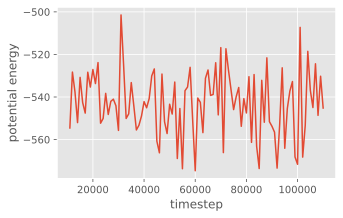

In [18]:
timestep = hdf5_file["hoomd-data/Simulation/timestep"][:]
potential_energy = hdf5_file[
    "hoomd-data/md/compute/ThermodynamicQuantities/potential_energy"
][:]

fig = matplotlib.figure.Figure(figsize=(5, 3.09))
ax = fig.add_subplot()
ax.plot(timestep, potential_energy)
ax.set_xlabel("timestep")
ax.set_ylabel("potential energy")
fig

In [19]:
hdf5_file["hoomd-data/md/compute/ThermodynamicQuantities/pressure_tensor"]

<HDF5 dataset "pressure_tensor": shape (100, 6), type "<f8">